## Section 2.2: Probability & Random Variables
**Topics:** Probability Axioms, Conditional Probability, Discrete Random Variables, Continues Random Variables

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1ijMqYpjx8opJ08G1TRFdmAlZ1XuZCkjl?usp=sharing)

In [ ]:
# Import Necessary Packages
import numpy as np
import matplotlib.pyplot as plt
# Formatting and Spacing:
np.set_printoptions(formatter={'int': str})

## Section 2.2.1: Probability Axioms


Probability axioms dictate how probability of events is used to measure uncertanity of events given in an experiment and sample size, S. Here, we show how axioms may be used.

* Given event A, 1 ≥ P(A) ≥ 0.
* Given sample space S, P(S) = 1
* Union of all disjoint events is equal to the sum of all disjoint events.
* Given event A and complement event A', P(A) + P(A') = 1.
* Given mutually exclusive events A and B, P(A U B) = P(A) + P(B)
* Given events A and B: P(A u B) = P(A) + P(B) - P(A n B)



For our example, we use a 20-sided die to demonstrate how probabilities might be calculated for various conditions.

In [ ]:
# Create 1 20-sided die. Check if the sample space is right.
outcome1 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])
probabilities = np.ones(len(outcome1)) / len(outcome1) # Corrected line: use integer for np.ones shape and then divide for probabilities
# Event A: Probability that the die rolls a number divisible by 3
# Event B: Probability that the die rolls a number less than 10
event_a = outcome1 % 3 == 0
event_b = outcome1 <= 10
print("What's the sample space?", outcome1)
print("Now, let's check the probabilities.")
print("Are all probabilities of outcome 1 non-negative?", np.all(probabilities > 0))
# Note: For this case, probability should be 1. It gives a rounding error of 1.0000000000000002.
print("What's the total probability?", probabilities.sum())
# Calculates Probability that event A and B occurs.
print("P(A : divisible by 3) =", round(np.sum(probabilities[event_a]), 4))
print("P(B : at most 10) =", round(np.sum(probabilities[event_b]), 4))
# Calculate Union and Intersection of A and B.
print("P(A union B) =", round(np.sum(probabilities[event_a | event_b]), 4))
print("P(A intersect B) =", round(np.sum(probabilities[event_a & event_b]), 4))
# Verify P(A u B):
print("Now, we verify the last axiom.")
print("Is P(A) + P(B) - P(A n B) = P(A u B)?", np.isclose(np.sum(probabilities[event_a]) + np.sum(probabilities[event_b]) - np.sum(probabilities[event_a & event_b]), np.sum(probabilities[event_a | event_b])))


What's the sample space? [1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20]
Now, let's check the probabilities.
Are all probabilities of outcome 1 non-negative? True
What's the total probability? 1.0000000000000002
P(A : divisible by 3) = 0.3
P(B : at most 10) = 0.5
P(A union B) = 0.65
P(A intersect B) = 0.15
Now, we verify the last axiom.
Is P(A) + P(B) - P(A n B) = P(A u B)? True


# Section 2.2.2: Conditional Probability

Conditional probability measures the probability of an event happening given knowledge of another event. This notation can be shown as P(A | B), or the probability of event A occurs given event B.

P(A|B) can be calculated using Bayes Theorem, using P(A | B) = P(A ∩ B) / P(B).

In this example, we demonstrate a false-postive case in disease diagnosis using randomized sesntivity, specificity, and false positive rates between 0 and 1.

In [ ]:
# Randomized Conditional Parameters for False Positive disease diagnosis case:
prevalance = np.random.rand()
sensitivity = np.random.rand()
false_positive_rate = np.random.rand()
# Calculate FP Rate and Disease Given Positive
p_positive = prevalance * sensitivity + (1 - prevalance) * false_positive_rate
p_disease_given_positive = prevalance * sensitivity / p_positive
# Print FP Rate.
print("Calculate False Positive Rate using Randomized Parameters")
print("---------------------------------------------------------")
print("Prevalance:", prevalance, "\nSensitivity:", sensitivity, "\nFalse Positive Rate:", false_positive_rate)
print("P(positive) =", round(p_positive, 4))
print("P(disease | positive) =", round(p_disease_given_positive, 4))

Calculate False Positive Rate using Randomized Parameters
---------------------------------------------------------
Prevalance: 0.403450094405582 
Sensitivity: 0.19900508279231188 
False Positive Rate: 0.3148838450923125
P(positive) = 0.2681
P(disease | positive) = 0.2994


## Section 2.2.3: Discrete Random Variables

Discrete random variables are finite and countable values, representing countable outcomes in a countable process or a random experiment. Probability Mass Functions use these variables to assign probabilties to outcome.

Using this example, we can demonstrate how discrete random variables may be represented, using a probabiltiy mass function.

CHECK 1: Does PMF sum to 1? True
CHECK 2: Are there ten variables? True
Expected Value and Variance: 
E[X] = 5.9
Var(X) = 3.3499999999999996


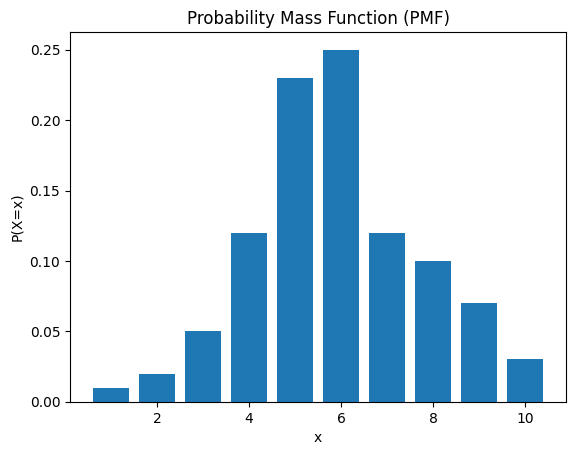

In [ ]:
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
pmf = np.array([0.01, 0.02, 0.05, 0.12, 0.23, 0.25, 0.12, 0.10, 0.07, 0.03])
expected_value = np.sum(x * pmf)
variance = np.sum((x - expected_value) ** 2 * pmf)

print(f"CHECK 1: Does PMF sum to 1? {np.isclose(sum(pmf), 1)}")
print(f"CHECK 2: Are there ten variables? {np.isclose(len(x), 10)}")
print("Expected Value and Variance: ")
print("E[X] =", expected_value)
print("Var(X) =", variance)

plt.bar(x, pmf, color="tab:blue")
plt.xlabel("x")
plt.ylabel("P(X=x)")
plt.title("Probability Mass Function (PMF)")
plt.show()

## Section 2.2.4: Continuous Random Variables


Unlike discrete random variables, continuous random variables measure values under an interval. Cumulative density functions use these variables to measure values less than or equal to specific points.

For instance, P(X ≤ x) measures the probability between -∞ exclusively and x inclusively.

In this example, we show a graphical representation of how continous random variables are shown in a Cumulative Density Function.

Random Rate: 0.2430
Approximate total area under PDF = 0.856815523842586
Approximate P(X <= 6) = 0.7670055886296037


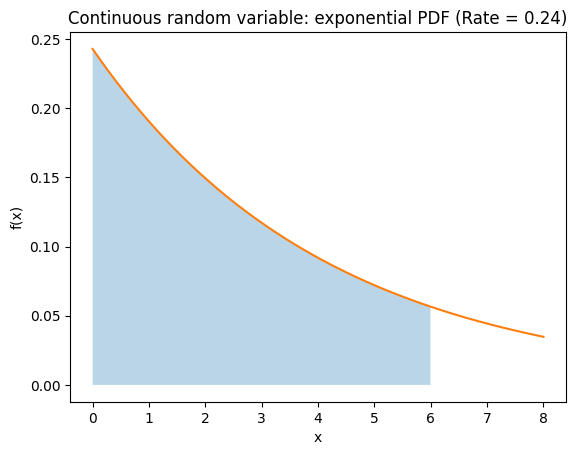

In [ ]:
grid = np.linspace(0, 8, 500)
# Random Rate between 0 to 1.
rate = np.random.rand()

pdf = rate * np.exp(-rate * grid)
approx_area = np.trapezoid(pdf, grid)
X = np.random.randint(10)
p_less_than_X = np.trapezoid(pdf[grid <= X], grid[grid <= X])

# Radnom Results:
print(f"Random Rate: {rate:.4f}")
print("Approximate total area under PDF =", approx_area)
print(f"Approximate P(X <= {X}) =", p_less_than_X)
# Graphical Representation of P(X <= 2) using different rates.
plt.plot(grid, pdf, color="tab:orange")
plt.fill_between(grid[grid <= X], pdf[grid <= X], alpha=0.3)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(f"Continuous random variable: exponential PDF (Rate = {rate:.2f})")
plt.show()